# 5.0 - Memory-budget Ablation

The money figure of the whole study. It runs SmartReplay across a grid of budgets
{1, 5, 15, 50} exemplars per class and three selection strategies {random, hard, diverse},
plus Naive at 0 bytes as the floor, and plots average accuracy against bytes-per-class.

Every configuration goes through the same `run_cl_stream` (base -> task1 -> task2) so only
the replay budget and strategy change. The result is a curve, not a point: it shows how
much accuracy each byte of memory buys, and where the return flattens.

## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "embeddings"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

## **Download DATASET**

Drive only - the cache is on Drive, no video needed.

In [2]:
from src.bootstrap import setup
setup(drive=True, dataset=False)

Drive mounted.
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [3]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
GPU       : Tesla T4 (15.6 GB)
Classes   : base=10 t1=10 t2=10 t3=10 t4=10


42

## **Load Cache and Base Head**

The same cache and `head_base.pt` every other continual-learning notebook uses, so this
ablation sits on the identical starting point.

In [4]:
CACHE, LSTM_STATE, META = load_feature_cache(cfg.FEAT_CACHE)

ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
check_cache_labels(META, ALL_CLASSES_LIST)

class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
TASK_CLASSES = [cfg.SELECTED_CLASSES, cfg.TASK_1, cfg.TASK_2]
TASK_NAMES   = ["Base", "Task1", "Task2"]
NUM_AFTER    = [len(cfg.SELECTED_CLASSES),
                len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
                len(ALL_CLASSES_LIST)]
print(f"head widths per task: {NUM_AFTER}")

Loaded 9 tensors, 526 MB in RAM
  per clip: (16, 2048)
head widths per task: [10, 20, 30]


In [5]:
head_base = load_or_train_base_head(
    f"{cfg.CKPT_DIR}/head_base.pt", CACHE, LSTM_STATE, len(cfg.SELECTED_CLASSES), device,
)

Loaded base head <- /content/drive/MyDrive/apai/checkpoints/head_base.pt


## **Read the Ceiling**

The joint linear probe from notebook 2.0. Every point on the curve is read against it.

In [6]:
CEILING = None
diag_path = f"{cfg.RESULTS_DIR}/stage2_embedding_diagnostics.json"
if os.path.exists(diag_path):
    with open(diag_path) as f:
        CEILING = json.load(f)["ceiling"]
print(f"ceiling: {CEILING:.2%}" if CEILING else "no ceiling json yet")

ceiling: 80.15%


## **The Sweep**

Naive first (0 bytes), then every budget x strategy. Each call trains base -> task1 ->
task2 on the cache, so all thirteen runs together are a few minutes. `verbose=False`
keeps the per-task chatter down; the accuracy matrix of each run is kept.

In [7]:
CL_EPOCHS, CL_LR, CL_WD, CL_BATCH, CL_LS = 15, 5e-4, 0.03, 32, 0.10

BUDGETS    = [1, 5, 15, 50]
STRATEGIES = ["random", "hard", "diverse"]

TRIALS = []

In [8]:
set_seed(cfg.SEED)
naive = run_cl_stream(
    head_base, CACHE, [1, 2], TASK_CLASSES, TASK_NAMES, NUM_AFTER,
    class_to_idx, cfg.SELECTED_CLASSES, device,
    CL_EPOCHS, CL_LR, CL_WD, CL_BATCH, CL_LS,
    arm="naive", replay_per_class=0, verbose=False,
)
R = build_accuracy_matrix(naive["rows"])
TRIALS.append({"per_class": 0, "strategy": "none", "AA": average_accuracy(R),
               "forgetting": forgetting_measure(R), "bytes": 0})
print(f"naive: AA={TRIALS[-1]['AA']:.2%}  bytes=0")

  [naive] ep 01/15 | CE 1.5458 | val Ba0=0% Ta1=80%
  [naive] ep 05/15 | CE 0.6239 | val Ba0=0% Ta1=86%
  [naive] ep 10/15 | CE 0.6078 | val Ba0=0% Ta1=84%
  [naive] ep 15/15 | CE 0.6053 | val Ba0=0% Ta1=85%
  [naive] ep 01/15 | CE 1.7925 | val Ba0=0% Ta1=1% Ta2=73%
  [naive] ep 05/15 | CE 0.6851 | val Ba0=0% Ta1=4% Ta2=84%
  [naive] ep 10/15 | CE 0.6591 | val Ba0=0% Ta1=3% Ta2=81%
  [naive] ep 15/15 | CE 0.6566 | val Ba0=0% Ta1=2% Ta2=83%
naive: AA=28.63%  bytes=0


In [9]:
for pc in BUDGETS:
    for strat in STRATEGIES:
        set_seed(cfg.SEED)
        res = run_cl_stream(
            head_base, CACHE, [1, 2], TASK_CLASSES, TASK_NAMES, NUM_AFTER,
            class_to_idx, cfg.SELECTED_CLASSES, device,
            CL_EPOCHS, CL_LR, CL_WD, CL_BATCH, CL_LS,
            arm=f"replay_{strat}_{pc}", replay_per_class=pc, replay_strategy=strat,
            verbose=False,
        )
        R = build_accuracy_matrix(res["rows"])
        TRIALS.append({"per_class": pc, "strategy": strat,
                       "AA": average_accuracy(R), "forgetting": forgetting_measure(R),
                       "bytes": res["bytes_per_class"]})
        print(f"  pc={pc:>2} {strat:<8} AA={TRIALS[-1]['AA']:.2%}  "
              f"{res['bytes_per_class']/1e3:.0f} KB/class")

  [replay_random_1] ep 01/15 | CE 1.5509 | val Ba0=6% Ta1=75%
  [replay_random_1] ep 05/15 | CE 0.6316 | val Ba0=34% Ta1=85%
  [replay_random_1] ep 10/15 | CE 0.6106 | val Ba0=32% Ta1=86%
  [replay_random_1] ep 15/15 | CE 0.6076 | val Ba0=32% Ta1=86%
  [replay_random_1] ep 01/15 | CE 1.7693 | val Ba0=0% Ta1=7% Ta2=82%
  [replay_random_1] ep 05/15 | CE 0.6943 | val Ba0=30% Ta1=18% Ta2=80%
  [replay_random_1] ep 10/15 | CE 0.6629 | val Ba0=24% Ta1=20% Ta2=82%
  [replay_random_1] ep 15/15 | CE 0.6596 | val Ba0=27% Ta1=20% Ta2=82%
  pc= 1 random   AA=44.13%  131 KB/class
  [replay_hard_1] ep 01/15 | CE 1.5247 | val Ba0=0% Ta1=82%
  [replay_hard_1] ep 05/15 | CE 0.6408 | val Ba0=21% Ta1=84%
  [replay_hard_1] ep 10/15 | CE 0.6102 | val Ba0=24% Ta1=86%
  [replay_hard_1] ep 15/15 | CE 0.6087 | val Ba0=24% Ta1=86%
  [replay_hard_1] ep 01/15 | CE 1.8053 | val Ba0=0% Ta1=4% Ta2=73%
  [replay_hard_1] ep 05/15 | CE 0.7065 | val Ba0=18% Ta1=12% Ta2=83%
  [replay_hard_1] ep 10/15 | CE 0.6636 | val Ba

## **Table**

Every configuration, sorted by accuracy.

In [10]:
mem_df = pd.DataFrame(TRIALS).sort_values("AA", ascending=False).reset_index(drop=True)
mem_df["KB_class"] = mem_df["bytes"] / 1e3
print(mem_df.to_string(index=False))

 per_class strategy       AA  forgetting   bytes  KB_class
        50  diverse 0.821288    0.091275 6553600  6553.600
        50   random 0.815583    0.079645 6553600  6553.600
        50     hard 0.806221    0.086775 6553600  6553.600
        15   random 0.767858    0.186723 1966080  1966.080
        15  diverse 0.751609    0.186669 1966080  1966.080
        15     hard 0.701362    0.282225 1966080  1966.080
         5   random 0.666043    0.339720  655360   655.360
         5  diverse 0.665726    0.346742  655360   655.360
         5     hard 0.615579    0.435603  655360   655.360
         1   random 0.441299    0.694353  131072   131.072
         1     hard 0.405889    0.729676  131072   131.072
         1  diverse 0.405889    0.729676  131072   131.072
         0     none 0.286319    0.911519       0     0.000


## **Accuracy vs Memory**

One line per strategy across the budget grid, Naive as the 0-byte floor, the ceiling as
the dashed line. Where a line flattens, extra exemplars stop paying for themselves.

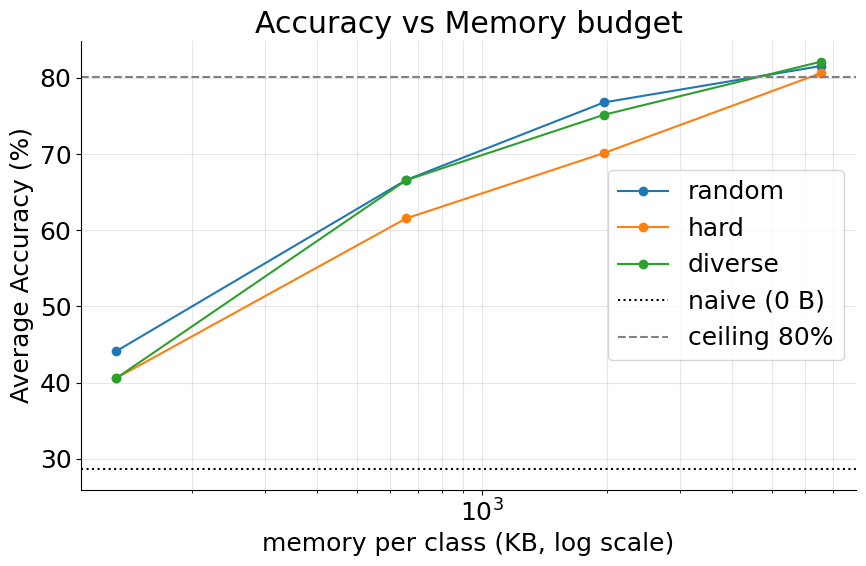

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

for strat in STRATEGIES:
    sub = mem_df[mem_df["strategy"] == strat].sort_values("bytes")
    ax.plot(sub["KB_class"].clip(lower=0.5), sub["AA"] * 100, marker="o", label=strat)

naive_aa = mem_df[mem_df["strategy"] == "none"]["AA"].iloc[0] * 100
ax.axhline(naive_aa, ls=":", color="black", label="naive (0 B)")

if CEILING is not None:
    ax.axhline(CEILING * 100, ls="--", color="gray", label=f"ceiling {CEILING:.0%}")

ax.set_xscale("log")
ax.set_xlabel("memory per class (KB, log scale)")
ax.set_ylabel("Average Accuracy (%)")
ax.set_title("Accuracy vs Memory budget")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/stage5_accuracy_vs_memory.png", dpi=150, bbox_inches="tight")
plt.show()

## **Save**

In [ ]:
payload = {"stage": "5_memory_ablation", "ceiling": CEILING, "trials": TRIALS}
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
with open(f"{cfg.RESULTS_DIR}/stage5_memory_ablation.json", "w") as f:
    json.dump(payload, f, indent=2, default=float)
print(f"Saved -> {cfg.RESULTS_DIR}/stage5_memory_ablation.json")

Saved -> /content/drive/MyDrive/apai/results/stage5_memory_ablation.json


: 